## Data loading

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

train = pd.read_csv('/kaggle/input/credit-score-classification/train.csv')
test  = pd.read_csv('/kaggle/input/credit-score-classification/test.csv')

train.drop_duplicates(inplace=True)
test.drop_duplicates(inplace=True)
train.shape, test.shape

((100000, 28), (50000, 27))

## Baseline model

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc

def BaseLine(df):
    
    df = df.dropna()
    features = df.drop(['Credit_Score'], axis=1)
    target   = df['Credit_Score']
    
    cat_features = features.select_dtypes('object')
    for col in cat_features.columns:
        features[col],_ = pd.factorize(features[col]) 

    model = LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.7, C=1, multi_class='multinomial')
    Pipe_lr = Pipeline([ ('scaler', StandardScaler()), ('lr_model', model)])
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_validate(estimator=Pipe_lr, X=features, y=target, cv=cv,
                            scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'roc_auc_ovr'])
    report = pd.DataFrame(scores)
    return report

base = BaseLine(train)
base

,fit_time,score_time,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_roc_auc_ovr
0,6.106792,0.277837,0.586051,0.573756,0.500637,0.515904,0.750187
1,6.071985,0.174242,0.590009,0.575491,0.499835,0.516052,0.747459
2,6.092816,0.186353,0.578794,0.562605,0.491887,0.505970,0.741940
3,6.108166,0.184654,0.582752,0.562942,0.494018,0.508458,0.746686
4,6.146058,0.179547,0.581676,0.565693,0.495954,0.510521,0.751209


## Exploratory data (EDA)

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

In [4]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import matplotlib.pyplot as plt
%matplotlib inline
import plotly.io as pio
pio.renderers.default = "kaggle"


X = train.drop(['Credit_Score', 'ID', 'Customer_ID'], axis=1)
y = train['Credit_Score']

ForPie = []
for col, val in X.nunique().items():
    if 2<val<=16:
        ForPie.append(col)
        
def Plot_Pie(data, columns, title=''):
    fig = make_subplots(rows=1, cols=len(columns), subplot_titles=columns, specs=[[{'type':'domain'}]*len(columns)])
    for i,col in enumerate(columns, start=1):
        fig.add_trace(
            go.Pie(labels=data[col].value_counts().index, values=data[col].value_counts().values, textinfo='label+percent',
                   insidetextorientation='radial'),
            row=1, col=i
        )
    fig.update_layout(height=400, width=470*len(columns), title=title, margin=dict(l=10,r=10,t=80,b=20),
                      title_x=0, title_font_color='darkblue', title_font_size=24)
    fig.show()

#======================================= Visualization...
# Categorical features
Plot_Pie(X, ForPie, 'Percentage of labels of each cat. column')

In [5]:
cat_features = X.select_dtypes('object')
num_features = X.select_dtypes(include= ['float', 'int'])

# null values..
print('Persentages of null values of each column:')
((train.isnull().sum().sort_values(ascending=False)*100)/train.shape[0]).head(10)

Persentages of null values of each column:


Monthly_Inhand_Salary      15.002
Type_of_Loan               11.408
Name                        9.985
Credit_History_Age          9.030
Num_of_Delayed_Payment      7.002
Amount_invested_monthly     4.479
Num_Credit_Inquiries        1.965
Monthly_Balance             1.200
Month                       0.000
Age                         0.000
dtype: float64

In [6]:
cat_features.head()

,Month,Name,Age,SSN,Occupation,Annual_Income,Num_of_Loan,Type_of_Loan,Num_of_Delayed_Payment,Changed_Credit_Limit,Credit_Mix,Outstanding_Debt,Credit_History_Age,Payment_of_Min_Amount,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
0,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",7,11.27,_,809.98,22 Years and 1 Months,No,80.41529543900253,High_spent_Small_value_payments,312.49408867943663
1,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",NaN,11.27,Good,809.98,NaN,No,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184
2,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",7,_,Good,809.98,22 Years and 3 Months,No,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912
3,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",4,6.27,Good,809.98,22 Years and 4 Months,No,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786
4,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",NaN,11.27,Good,809.98,22 Years and 5 Months,No,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177


##### SSN "Social Security Number":
Not important for analytical, and danger identifier cause leakage..

##### Month and Name:
Aren't important for analytical

In [7]:
X = X.drop(['SSN', 'Name', 'Month'], axis=1)
X_test = test.drop(['ID', 'Customer_ID', 'SSN', 'Name', 'Month'], axis=1)   

## Feature Engineering

In [8]:
# Create Feature of No.of loans insted of Type_of_Loans:
def no_loans(df):
    df['no_of_loan'] = df['Type_of_Loan'].str.count(',')+1
    df.drop(['Type_of_Loan', 'Num_of_Loan'], axis=1, inplace=True)

no_loans(X)
no_loans(X_test)

In [9]:
X['Payment_Behaviour']. unique()

array(['High_spent_Small_value_payments',
       'Low_spent_Large_value_payments',
       'Low_spent_Medium_value_payments',
       'Low_spent_Small_value_payments',
       'High_spent_Medium_value_payments', '!@9#%8',
       'High_spent_Large_value_payments'], dtype=object)

#### Wrong value (!@9#%8) in Payment_Behaviour needs to replaced by NaN, then break this column into spent and value_payments 

In [10]:
X['Payment_Behaviour'] = X['Payment_Behaviour'].replace(['!@9#%8'], np.nan)
X_test['Payment_Behaviour'] = X_test['Payment_Behaviour'].replace(['!@9#%8'], np.nan)

def PB_handling(df):
    df[['Spent', 'Value_Payments']] = df['Payment_Behaviour'].str.split('_', expand=True).iloc[:, [0,2]]
    df.drop(['Payment_Behaviour'], axis=1, inplace=True)

PB_handling(X)
PB_handling(X_test)

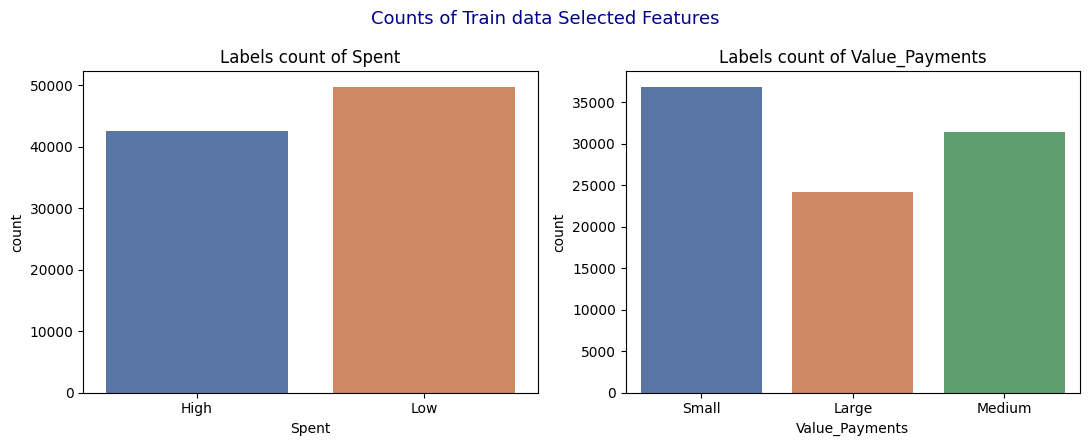

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

def Count_Plot(df, title=''):
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
    for i, col in enumerate(['Spent', 'Value_Payments']):
        sns.countplot(data=df, x=col, ax=ax[i], palette='deep')
        ax[i].set_title(f'Labels count of {col}')

    fig.suptitle(title, fontsize=13, color='darkblue')
    plt.tight_layout()
    plt.show()


Count_Plot(X, 'Counts of Train data Selected Features')

In [12]:
## Credit History breaking down:     "sample ex: 22 Years and 3 Months"
cols = ['Years', 'Months']
to_break = 'Credit_History_Age'

X = pd.concat([X,y], axis=1)    # h-stack between X, y
def CH_handling(df, cols, to_break, test=test):
        df[cols] = df[to_break].str.split(" ", expand=True).iloc[:, [0, 3]]
        df.dropna(subset=cols, inplace=True)
        df.drop([to_break], axis=1, inplace=True)
        if (df.shape[0]<50000):
            test = test.iloc[df.index] 
        df.reset_index(drop=True, inplace=True)
        return test

CH_handling(X, cols, to_break)

# Test data after update:
test = CH_handling(X_test, cols, to_break)

In [13]:
y = X['Credit_Score']
X = X.drop(['Credit_Score'], axis=1)

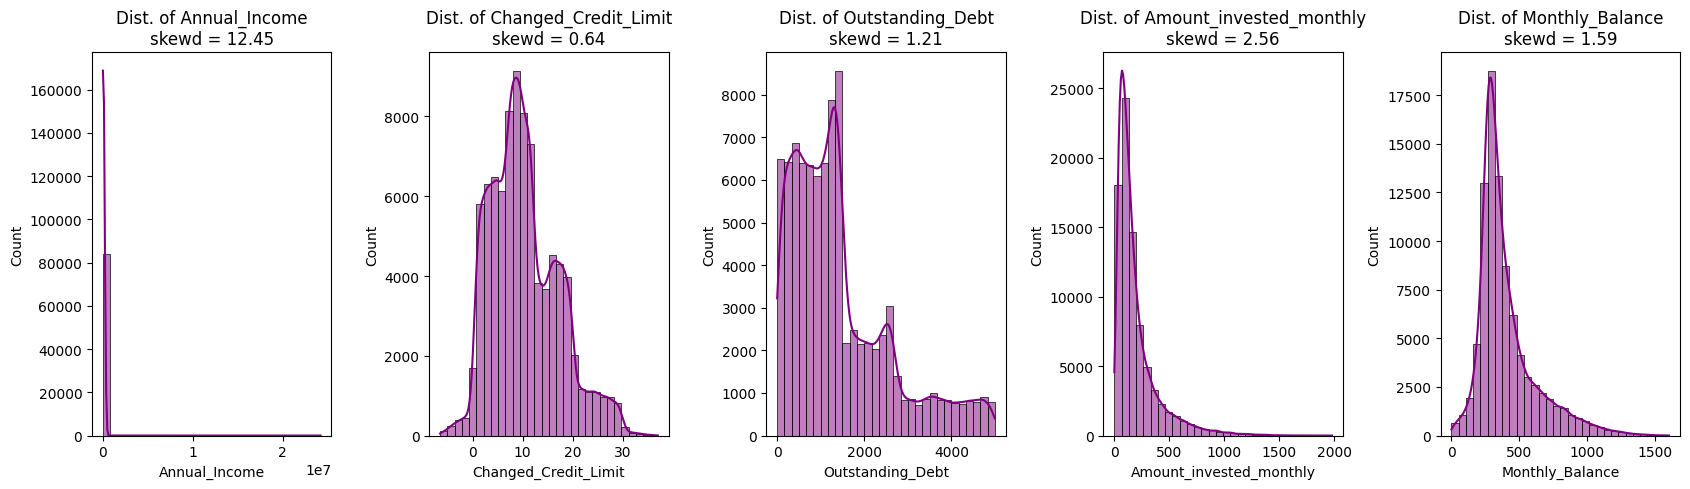

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt


to_float = ['Annual_Income', 'Changed_Credit_Limit', 'Outstanding_Debt', 'Amount_invested_monthly', 'Monthly_Balance']
to_int   = ['Age', 'Num_of_Delayed_Payment', 'Years', 'Months']

def converter(df, fcols, icols):
    df[fcols] = df[fcols].apply(pd.to_numeric, errors='coerce')
    df[fcols] = df[fcols].astype('float64')
    
    df[icols] = df[icols].apply(pd.to_numeric, errors='coerce')      # Defualtly, converting into float automatically.
    df[icols] = df[icols].astype('Int64')                            # Cannot usnig (.astype = int), due NaN values exists.., must Int64.

    # Build a new feature to avoid high cardinality:
    df['Credit_History_Months'] = df['Years']*12 + df['Months']
    df['Credit_History_Months'] = pd.to_numeric(df['Credit_History_Months'], errors='coerce')
    df['Credit_History_Months'] = df['Credit_History_Months'].astype('Int64')
    df.drop(['Years', 'Months'], axis=1, inplace=True)

converter(X, to_float, to_int)
converter(X_test, to_float, to_int)

to_int.append('Credit_History_Months')
for col in ['Years', 'Months']:
    to_int.remove(col)

def histo(df, cols):
    r, c = 1, len(cols)
    fig, ax = plt.subplots(r, c, figsize=(17, 5))
    for i, col in enumerate(cols):
        sns.histplot(data=df, x=col, color='purple', bins=30, ax=ax[i], kde=True)
        ax[i].set_title(f"Dist. of {col}\nskewd = {df[col].skew():.2f}")
    plt.tight_layout()
    plt.show()


histo(X, to_float)

#### All numerical features having a high skewness
#### We can normalize them as a pre-processing, or using a robust scaler in pipe for outliers

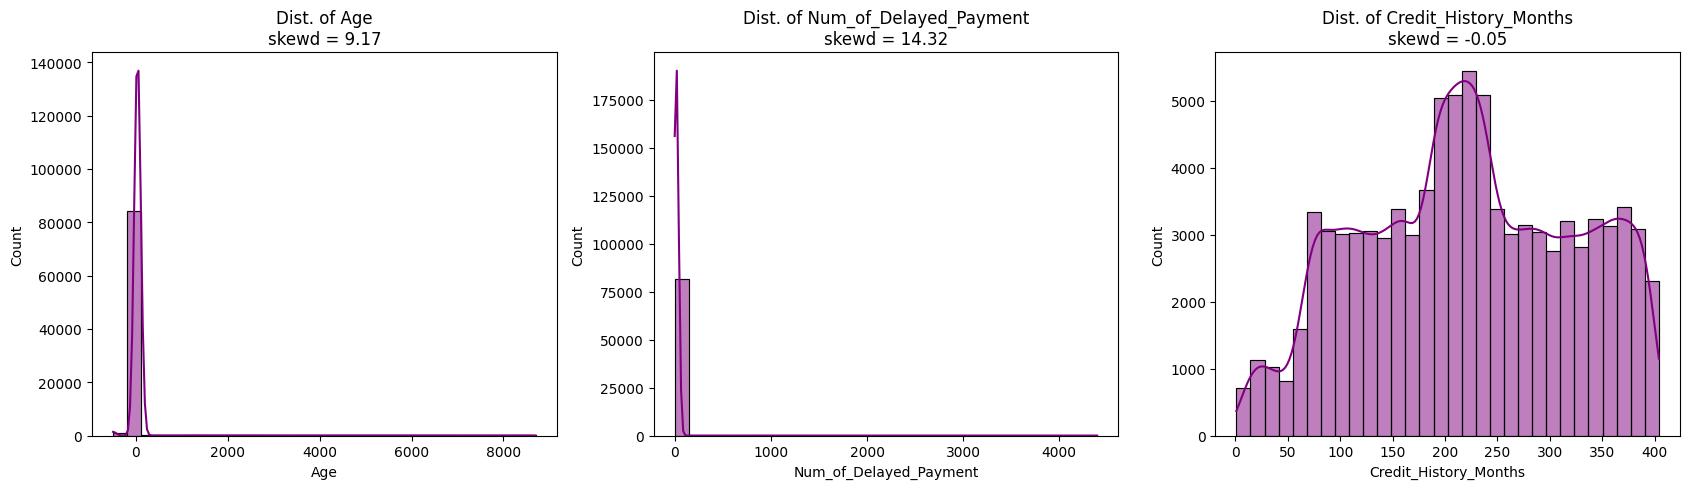

In [15]:
# Check distribution of integer features:
histo(X, to_int)

In [16]:
X['Age'].agg(['min', 'max', 'mean', 'median', 'std'])  

min       -500.000000
max       8698.000000
mean       111.116996
median      33.000000
std        690.214948
Name: Age, dtype: float64

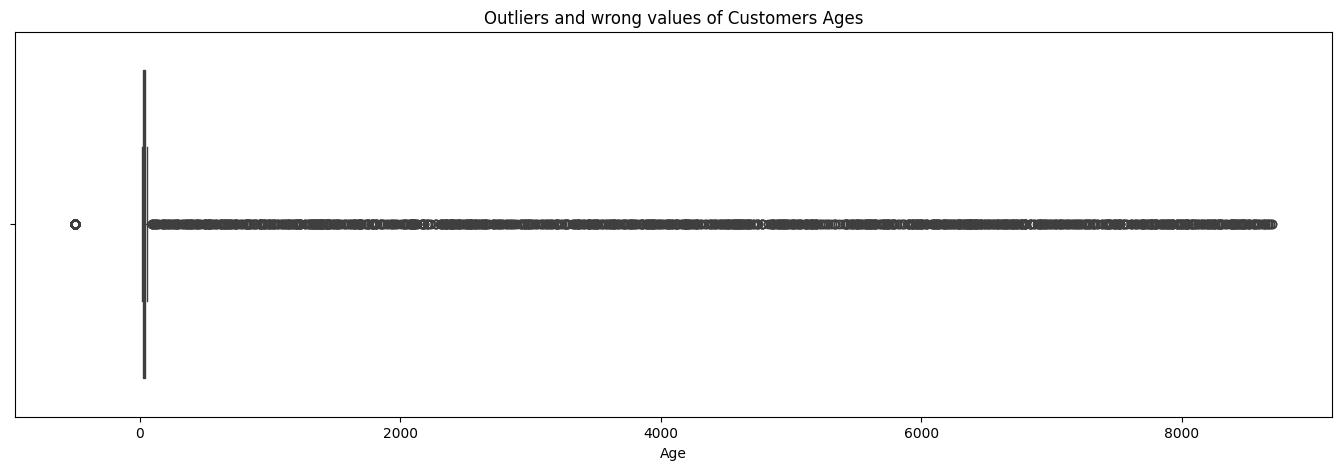

In [17]:
# Display Age outliers...

plt.figure(figsize=(17, 5))
sns.boxplot(data=X, x='Age')
plt.title('Outliers and wrong values of Customers Ages')
plt.show()

In [18]:
X = X.drop(['Age'], axis=1)
X_test = X_test.drop(['Age'], axis=1)

In [19]:
import plotly.express as px 

high_spent = X_test[X_test['Spent']=='Low']
occupation_counts = high_spent['Occupation'].value_counts().reset_index()
occupation_counts.columns = ['Occupation', 'Count'] 
fig = px.bar(data_frame=occupation_counts, y='Occupation', x='Count',
             orientation='h', color='Count',
             title='Count of Occupation for Low Spent', 
             labels={'Count':'Number of Clients', 'Occupation':'Occupation'}) 
fig.show()

In [20]:
def repl_values(df):
    df['Spent'] = df['Spent'].replace({'High':1, 'Low':0})
    df['Value_Payments'] = df['Value_Payments'].replace({'Small':0, 'Medium':1, 'Large':2})

repl_values(X)
repl_values(X_test)

In [21]:
X['Occupation'].unique()

array(['Scientist', '_______', 'Teacher', 'Engineer', 'Entrepreneur',
       'Developer', 'Lawyer', 'Media_Manager', 'Doctor', 'Journalist',
       'Manager', 'Accountant', 'Musician', 'Mechanic', 'Writer',
       'Architect'], dtype=object)

In [22]:
X['Occupation'] = X['Occupation'].replace(['_______'], 'Others')
X_test['Occupation'] = X_test['Occupation'].replace(['_______'], 'Others')

In [23]:
cols = ['no_of_loan', 'Spent', 'Value_Payments', 'Credit_History_Months', 
            'Num_Bank_Accounts',	'Num_Credit_Card', 'Interest_Rate', 
            'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Num_Credit_Inquiries']


def new_f(df, cols):
    df['New_Count_feature'] = df[cols].gt(0).sum(axis=1)

new_f(X, cols)
new_f(X_test, cols)

### The data is now ready to train our model...

In [24]:
X.head()

,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,...,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,no_of_loan,Spent,Value_Payments,Credit_History_Months,New_Count_feature
0,Scientist,19114.12,1824.843333,3,4,3,3,7,11.27,4.0,...,26.822620,No,49.574949,80.415295,312.494089,4.0,1.0,0.0,265,9
1,Scientist,19114.12,NaN,3,4,3,3,7,NaN,4.0,...,28.609352,No,49.574949,81.699521,331.209863,4.0,0.0,1.0,267,9
2,Scientist,19114.12,NaN,3,4,3,5,4,6.27,4.0,...,31.377862,No,49.574949,199.458074,223.451310,4.0,0.0,0.0,268,8
3,Scientist,19114.12,1824.843333,3,4,3,6,<NA>,11.27,4.0,...,24.797347,No,49.574949,41.420153,341.489231,4.0,1.0,1.0,269,9
4,Scientist,19114.12,NaN,3,4,3,8,4,9.27,4.0,...,27.262259,No,49.574949,62.430172,340.479212,4.0,NaN,NaN,270,8


## Check target balance

In [25]:
## Check target balance:

Plot_Pie(pd.DataFrame(y.values, columns=['Target']), ['Target'], 'Percentages of target labels')

#### Imbalanced target...

In [26]:
!pip show imbalanced-learn

Name: imbalanced-learn
Version: 0.14.0
Summary: Toolbox for imbalanced dataset in machine learning
Home-page: https://imbalanced-learn.org/
Author: 
Author-email: "G. Lemaitre" <g.lemaitre58@gmail.com>, "C. Aridas" <ichkoar@gmail.com>
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: joblib, numpy, scikit-learn, scipy, threadpoolctl
Required-by: 


## Pipeline models

In [27]:
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OrdinalEncoder
from category_encoders import MEstimateEncoder
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc


cat_cols = X.select_dtypes('object').columns.tolist()
num_cols = X.select_dtypes(include=['float64', 'int64', 'Int64']).columns.tolist()

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

preprocessor = ColumnTransformer([
    ('cat', cat_pipe, cat_cols),
    ('num', num_pipe, num_cols)
])


XGBClf = ImbPipeline([
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(learning_rate=0.01, random_state=42))
])

y1 = y.copy()
y1 = y1.replace({'Poor':0, 'Standard':1, 'Good':2})
xg_scores = cross_validate(estimator=XGBClf, X=X, y=y1, cv=7,
                        scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'roc_auc_ovr_weighted'],
                        return_train_score=True, n_jobs=-1)

xg_scores_df = pd.DataFrame(xg_scores)

In [28]:
from sklearn.ensemble import RandomForestClassifier

RFClf = ImbPipeline([
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=50, random_state=42))
])

random_scores = cross_validate(estimator=RFClf, X=X, y=y, cv=7,
                        scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'roc_auc_ovr_weighted'],
                        return_train_score=True, n_jobs=-1)

random_scores_df = pd.DataFrame(random_scores)

In [29]:
from sklearn.ensemble import HistGradientBoostingClassifier

HGBClf = ImbPipeline([
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('hgb', HistGradientBoostingClassifier(max_iter=100, max_depth=10, random_state=42))
])

hist_scores = cross_validate(estimator=HGBClf, X=X, y=y, cv=7,
                        scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'roc_auc_ovr_weighted'],
                        return_train_score=True, n_jobs=-1)

hist_scores_df = pd.DataFrame(hist_scores)

In [30]:
Report = pd.DataFrame()

all_models = {'XGBoost':xg_scores_df, 'Random Forest':random_scores_df, 'Hist Gradient Boosting':hist_scores_df}
for model,scores in all_models.items():
    metrics = {
        'Train Mean Accuracy': scores['train_accuracy'].mean(),
        'Test Mean Accuracy' : scores['test_accuracy'].mean(),
        'Train Mean Recall'  : scores['train_recall_macro'].mean(),
        'Test Mean Recall'   : scores['test_recall_macro'].mean(),
        'Train Mean ROC-AUC' : scores['train_roc_auc_ovr_weighted'].mean(),
        'Test Mean ROC-AUC'  : scores['test_roc_auc_ovr_weighted'].mean(),
    }
    
    Report[model] = metrics
Report.index.name = 'Metric'
Report = Report.round(4).sort_values(by='Test Mean ROC-AUC', axis=1, ascending=False)

Report

,Hist Gradient Boosting,XGBoost,Random Forest
Metric,,,
Train Mean Accuracy,0.7640,0.6912,0.9998
Test Mean Accuracy,0.6945,0.6826,0.6889
Train Mean Recall,0.7634,0.7207,0.9999
Test Mean Recall,0.6825,0.7121,0.6839
Train Mean ROC-AUC,0.8863,0.8299,1.0000
Test Mean ROC-AUC,0.8296,0.8219,0.8200


#### Hist Gradient Boosting achieved the best generalization performance, showing the highest test ROC-AUC and accuracy with a reasonable train–test gap, indicating good bias–variance trade-off.

## Model Evaluation

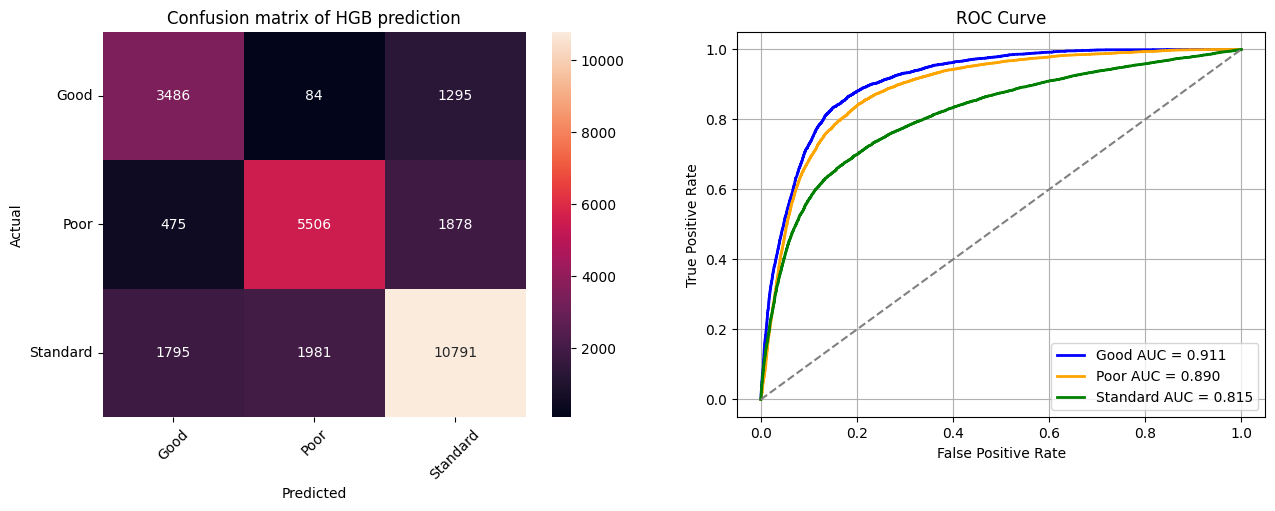

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import classification_report, confusion_matrix

X_train, X_valid, y_train, y_valid = train_test_split(X,y, test_size=.3, random_state=42)

best_model = HGBClf
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_valid)
y_pred_proba = best_model.predict_proba(X_valid)

classes = best_model.classes_
y_valid_bin = label_binarize(y_valid, classes=classes)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(confusion_matrix(y_valid, y_pred), annot=True, fmt='d', ax=ax[0], xticklabels=classes, yticklabels=classes)
ax[0].tick_params(axis='x', rotation=45)
ax[0].tick_params(axis='y', rotation=0)
ax[0].set_title('Confusion matrix of HGB prediction')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

colors = ['blue', 'orange', 'green']
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_valid_bin[:, i], y_pred_proba[:, i])
    auc_score = roc_auc_score(y_valid_bin[:, i], y_pred_proba[:, i])
    ax[1].plot(fpr, tpr, label=f'{cls} AUC = {auc_score:.3f}', color=colors[i], lw=2)

ax[1].plot([0,1], [0,1], linestyle='--', color='gray')
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('ROC Curve')

plt.legend()
plt.grid()
plt.show()

## Prediction on test file (unseen data)..

In [32]:
prediction = best_model.predict(X_test)
submission = pd.DataFrame({'ID':test['ID'].reset_index(drop=True), 'Credit_Score':prediction})
submission.to_csv('Credit_Score_Prediction.csv', index=False)

print('✅ Predictions saved!')
print(f'\n📊 Prediction Classes Counts:')
print(submission['Credit_Score'].value_counts(), '\n')

submission

✅ Predictions saved!

📊 Prediction Classes Counts:
Credit_Score
Standard    22966
Poor        12726
Good         9838
Name: count, dtype: int64 



,ID,Credit_Score
0,0x160a,Good
1,0x160b,Good
2,0x160d,Good
3,0x1616,Good
4,0x1617,Good
...,...,...
45525,0x25fe4,Standard
45526,0x25fee,Standard
45527,0x25fef,Poor
45528,0x25ff0,Good


## Conclusions

1. **Best Model:** Histogram-Based Gradient Boosting achieved the highest performance
2. **Class Imbalance:** The most common class is Standard credit score, representing approximately 50.7% of the samples
3. **Spending Behavior by Occupation:** Scientists represent the lowest occupation category (~ 3.29%), while Lawyers represent the highest (~ 2.52%)



#### 📧 Contact: [salahmostafaa21@gmail.com](http://) | 🔗 LinkedIn: [www.linkedin.com/in/salah-mostafa](http://)